# Install Triton and verify installation

In [1]:
# Select GPU T4 x 2 accelator and install triton
!pip install triton

In [2]:
# Verify installation
import torch
import triton
import triton.language as tl 

# Check if Triton can access the GPU
print(f"Triton version: {triton.__version__}")
print(f"GPU Available: {torch.cuda.is_available()}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")

# Simple test: define a JIT kernel
@triton.jit
def dummy_kernel(x_ptr):
    return

print("Triton JIT check: Success")

Triton version: 3.5.0
GPU Available: True
GPU Name: Tesla T4
Triton JIT check: Success


In [3]:
# Set cache directory
import os
os.environ["TRITON_CACHE_DIR"] = "/kaggle/working/triton_cache"

# Set device
current_device_id = torch.cuda.current_device()
DEVICE = torch.device(f"cuda:{current_device_id}")

# ReLU

### Kernel and Wrapper

In [4]:
@triton.jit
def relu_kernel(
    z_ptr,
    a_ptr,
    n_elements,
    BLOCK_SIZE: tl.constexpr,
):
    # 1D program id
    pid = tl.program_id(axis=0)
    
    # Compute start position and offset
    block_start = pid * BLOCK_SIZE
    offsets = block_start + tl.arange(0, BLOCK_SIZE)

    # Mask for out-of-bound
    mask = offsets < n_elements

    # Load input
    z = tl.load(z_ptr + offsets, mask=mask, other=0.0)

    # Apply ReLU
    a = tl.maximum(z, 0)

    # Store output
    tl.store(a_ptr + offsets, value=a, mask=mask)
    

def relu(z):
    # Input dimens
    n_rows, n_cols = z.shape
    
    # Allocate output
    a = torch.empty_like(z)

    # Define launch grid
    n_elements = z.numel()
    grid = lambda meta: (triton.cdiv(n_elements, meta["BLOCK_SIZE"]),)

    # Call kernel
    relu_kernel[grid](z, a, n_elements, BLOCK_SIZE=1024)

    return a

### Test and Benchmark Helpers

In [5]:
def test_relu_kernel(size: tuple, atol=1e-6, rtol=1e-5, device=DEVICE):
    # Set random seed
    torch.manual_seed(42)

    assert isinstance(size, tuple) and len(size) == 2
    
    # Create test data
    m, n = size
    z = torch.randn(m, n, device=device)

    # Run triton kernel and PyTorch equivalent
    a_triton = relu(z)
    a_ref = torch.nn.functional.relu(z)

    # Compare
    torch.testing.assert_close(a_triton, a_ref, atol=atol, rtol=rtol)
    print("Passed")


@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["N"], # x-axis for plot
        x_vals=[128 * i for i in range(1, 100)], # Different possible values for x_name
        x_log=True, # Log scale for x-axis,
        line_arg="provider",
        line_vals=["triton", "torch"],
        line_names=["Triton", "Torch"], # Label names for the lines
        styles=[("blue", '-'), ("red", '-')], # Line styles
        ylabel="GB/sec", # Label name for y-axis
        plot_name="relu-performance",
        args={'M': 4096}, # Values for function argument not in x_names and y_name
    )
)
def benchmark(M, N, provider):
    # Create input data
    z = torch.randn(M, N, device=DEVICE, dtype=torch.float32)
    quantiles = [0.1, 0.5, 0.9]
    if provider == "torch":
        min_ms, ms, max_ms = triton.testing.do_bench(lambda: torch.nn.functional.relu(z), quantiles=quantiles)
    if provider == "triton":
        # Call wrapper
        min_ms, ms, max_ms = triton.testing.do_bench(lambda: relu(z), quantiles=quantiles)
    
    gbps = lambda ms: 2 * z.numel() * z.element_size() * 1e-9 / (ms * 1e-3) # 2 is used because 1 read and 1 write

    return gbps(min_ms), gbps(ms), gbps(max_ms)

## Test

In [6]:
test_relu_kernel((1025, 4100))
test_relu_kernel((2048, 4096))

Passed
Passed


## Benchmark

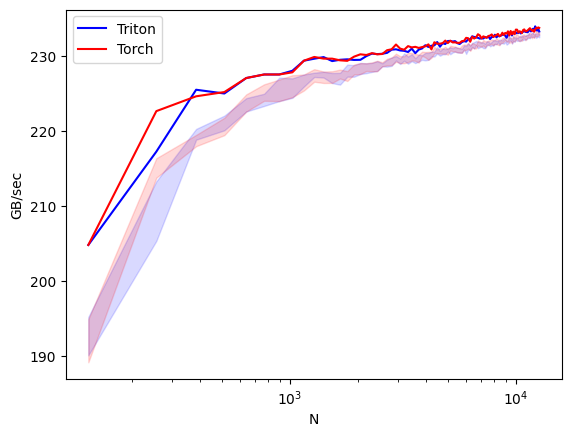

relu-performance:
          N      Triton       Torch
0     128.0  204.800005  204.800005
1     256.0  217.258414  222.665421
2     384.0  225.519614  224.643504
3     512.0  225.016305  225.209619
4     640.0  227.082460  227.082460
5     768.0  227.555555  227.555555
6     896.0  227.555557  227.555557
7    1024.0  228.050452  227.842342
8    1152.0  229.396393  229.396393
9    1280.0  229.660773  229.894413
10   1408.0  229.877559  229.672485
11   1536.0  229.343986  229.668828
12   1664.0  229.517236  229.446152
13   1792.0  229.579761  229.375989
14   1920.0  229.497257  229.934742
15   2048.0  229.512980  230.248793
16   2176.0  230.005470  230.155147
17   2304.0  230.346018  230.400006
18   2432.0  230.274066  230.248512
19   2560.0  230.322625  230.290255
20   2688.0  230.439857  230.795398
21   2816.0  230.865877  230.919481
22   2944.0  230.916104  231.554623
23   3072.0  230.760556  231.002891
24   3200.0  230.711823  230.861357
25   3328.0  230.557606  231.340164
26   3456.

In [7]:
benchmark.run(print_data=True, show_plots=True)